In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [2]:
months = ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6','Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']
features = ['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA', 'Percent_Bleaching']

In [3]:
df = pd.read_csv("../best_data.csv")

In [4]:
df = df[features + months]

# PCA

In [5]:
X = df.drop("Percent_Bleaching", axis=1)
Y = df["Percent_Bleaching"]

In [6]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [7]:
X_train_raw_month, X_test_raw_month = X_train_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy(), X_test_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

X_train_raw_fe, X_test_fe = X_train_raw[['Depth_m', 'ClimSST', 'SSTA']].copy(), \
       X_test_raw[['Depth_m', 'ClimSST', 'SSTA']].copy()

X_train_raw_coor, X_test_coor = X_train_raw[['Latitude_Degrees', 'Longitude_Degrees']].copy(), \
       X_test_raw[['Latitude_Degrees', 'Longitude_Degrees']].copy()


X_train_raw = X_train_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'Latitude_Degrees', 'Longitude_Degrees'])
X_test_raw = X_test_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'Latitude_Degrees', 'Longitude_Degrees'])

In [8]:
# 1. Imputer สำหรับข้อมูลดิบหลัก
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

# 2. SEPARATE imputer for FE — and keep as DataFrame
fe_imputer = SimpleImputer(strategy='median')
X_train_raw_fe = pd.DataFrame(
    fe_imputer.fit_transform(X_train_raw_fe),
    columns=X_train_raw_fe.columns,
    index=X_train_raw_fe.index
)
X_test_fe = pd.DataFrame(
    fe_imputer.transform(X_test_fe),
    columns=X_test_fe.columns,
    index=X_test_fe.index
)

# 3. SEPARATE imputer for COOR — and keep as DataFrame
coor_imputer = SimpleImputer(strategy='median')
X_train_raw_coor = pd.DataFrame(
    coor_imputer.fit_transform(X_train_raw_coor),
    columns=X_train_raw_coor.columns,  
    index=X_train_raw_coor.index      
)
X_test_coor = pd.DataFrame(
    coor_imputer.transform(X_test_coor),
    columns=X_test_coor.columns,     
    index=X_test_coor.index            
)

# 4. Scaler ตัวที่ 1 สำหรับข้อมูลหลัก
scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

# 5. Scaler ตัวที่ 2 แยกต่างหากสำหรับ COOR
coor_scaler = StandardScaler() 
X_train_ss_coor = coor_scaler.fit_transform(X_train_raw_coor)
X_test_ss_coor = coor_scaler.transform(X_test_coor)

# 6. PCA สำหรับฟีเจอร์หลัก (Environment)
pca_fe = PCA(n_components=1)
X_train_pca = pca_fe.fit_transform(X_train_ss)
X_test_pca = pca_fe.transform(X_test_ss)

# 7. PCA สำหรับพิกัด (Coordinates)
pca_coor = PCA(n_components=1)
X_train_coor_pca = pca_coor.fit_transform(X_train_ss_coor)
X_test_coor_pca = pca_coor.transform(X_test_ss_coor) # แก้ไขจาก fit_transform เป็น transform เพื่อป้องกันข้อมูลรั่วไหล

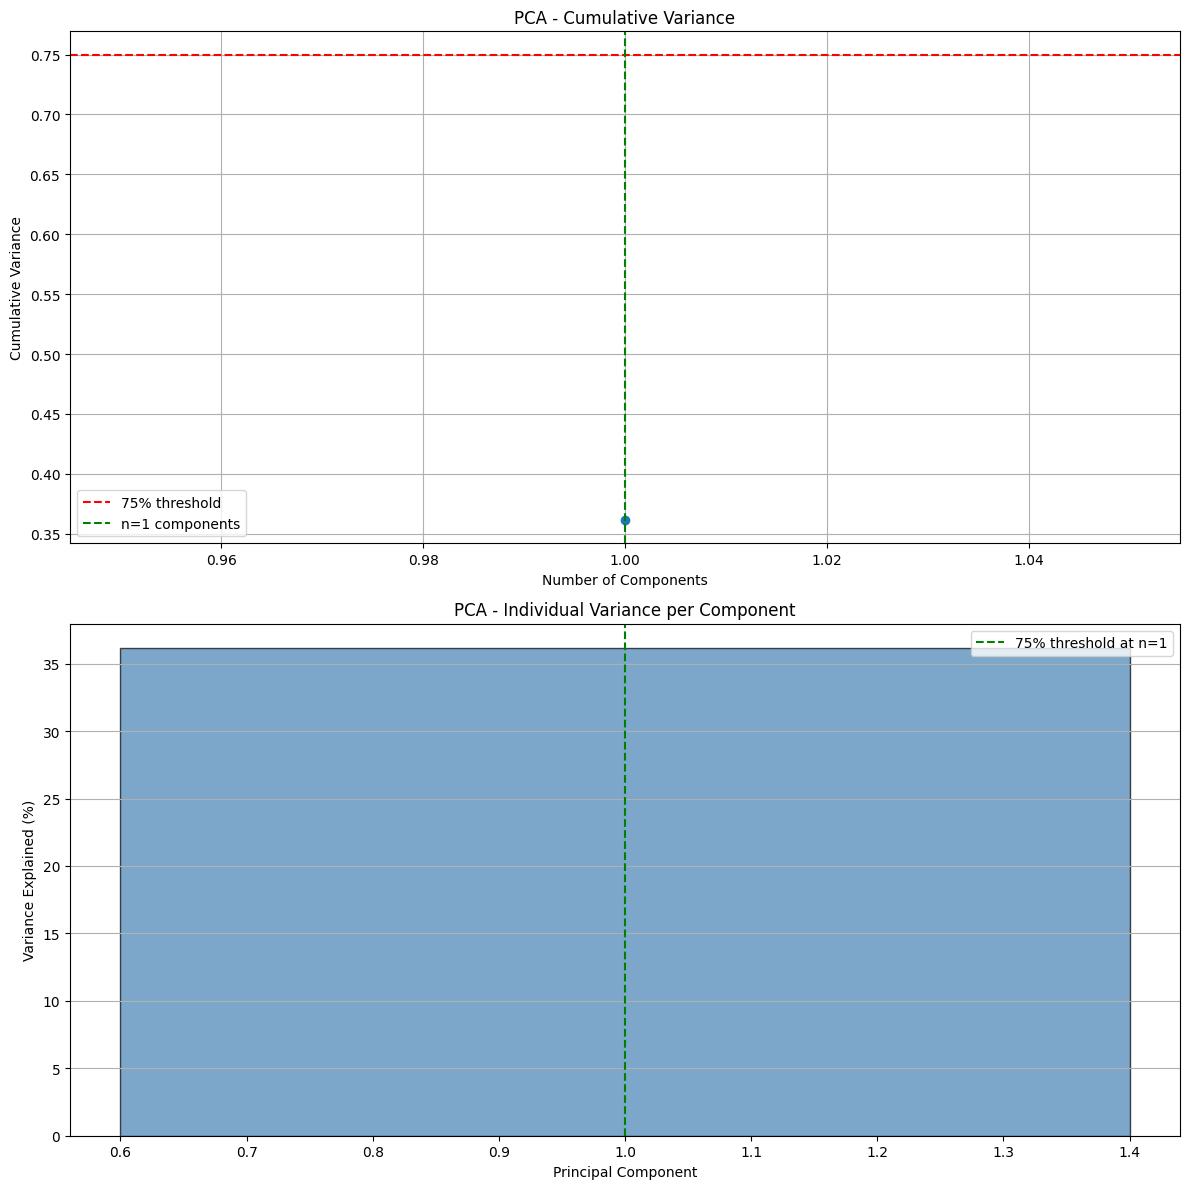

✅ Components needed for 75% variance: 1
✅ Variance explained by 1 components: 0.3615


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca_fe.explained_variance_ratio_)
n_components_75 = np.argmax(cumvar >= 0.75) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.75, color='r', linestyle='--', label='75% threshold')
ax1.axvline(x=n_components_75, color='g', linestyle='--', 
            label=f'n={n_components_75} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca_fe.explained_variance_ratio_)+1), 
        pca_fe.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_75, color='g', linestyle='--',
            label=f'75% threshold at n={n_components_75}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 75% variance: {n_components_75}")
print(f"✅ Variance explained by {n_components_75} components: {cumvar[n_components_75-1]:.4f}")

In [10]:
# สร้าง DataFrame สำหรับ PC1 ฝั่งสิ่งแวดล้อม
X_train_pca_env_df = pd.DataFrame(X_train_pca, columns=['PC1_env'])
X_test_pca_env_df = pd.DataFrame(X_test_pca, columns=['PC1_env'])

# สร้าง DataFrame สำหรับ PC1 ฝั่งพิกัด (Coordinates) ตาม Hypothesis A
X_train_pca_coor_df = pd.DataFrame(X_train_coor_pca, columns=['PC1_coor'])
X_test_pca_coor_df = pd.DataFrame(X_test_coor_pca, columns=['PC1_coor'])

# รีเซ็ต index ของข้อมูลดิบส่วนอื่นๆ เพื่อป้องกันปัญหาแถวเลื่อนหรือไม่ตรงกันตอนรวมตาราง
X_train_raw_month = X_train_raw_month.reset_index(drop=True)
X_test_raw_month = X_test_raw_month.reset_index(drop=True)

X_train_raw_fe = X_train_raw_fe.reset_index(drop=True)
X_test_fe = X_test_fe.reset_index(drop=True)

# รวมฟีเจอร์ทั้งหมดเข้าด้วยกันในแนวแกน X (axis=1) ประกอบด้วย: PC1_env, PC1_coor, เดือน และฟีเจอร์ที่ทำ FE
X_train_pca = pd.concat([X_train_pca_env_df, X_train_pca_coor_df, X_train_raw_month, X_train_raw_fe], axis=1)
X_test_pca  = pd.concat([X_test_pca_env_df,  X_test_pca_coor_df,  X_test_raw_month,  X_test_fe],       axis=1)

In [11]:
import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score


# OpTuna

In [12]:

# ============================================================
# Helper: CV with proper preprocessing within fold (Regression Workflow)
# ============================================================
def cv_regress(model_factory, X_env_raw, X_coor_raw, X_fe_raw, X_month_raw, y, cv_splits=5):
    """
    K-Fold CV สำหรับโมเดลถดถอย (Regression) ที่ทำการฟิตขั้นตอนการเตรียมข้อมูล
    แยกกันอย่างเด็ดขาดภายในแต่ละ Fold เพื่อป้องกันปัญหา Data Leakage
    """
    X_env_raw = X_env_raw.reset_index(drop=True)
    X_coor_raw = X_coor_raw.reset_index(drop=True)
    X_fe_raw = X_fe_raw.reset_index(drop=True)
    X_month_raw = X_month_raw.reset_index(drop=True)
    y = y.reset_index(drop=True)
    
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in kf.split(X_env_raw):
        # ----- 1. Split Data -----
        X_env_tr, X_env_val = X_env_raw.iloc[train_idx], X_env_raw.iloc[val_idx]
        X_coor_tr, X_coor_val = X_coor_raw.iloc[train_idx], X_coor_raw.iloc[val_idx]
        X_fe_tr, X_fe_val = X_fe_raw.iloc[train_idx], X_fe_raw.iloc[val_idx]
        X_month_tr, X_month_val = X_month_raw.iloc[train_idx], X_month_raw.iloc[val_idx]
        
        y_tr = y.iloc[train_idx].reset_index(drop=True)
        y_val = y.iloc[val_idx].reset_index(drop=True)
        
        # ----- 2. Preprocessing สำหรับ ข้อมูลหลัก (Environment) -----
        imputer_env = SimpleImputer(strategy='median')
        X_env_tr_imp = imputer_env.fit_transform(X_env_tr)
        X_env_val_imp = imputer_env.transform(X_env_val)
        
        scaler_env = StandardScaler()
        X_env_tr_ss = scaler_env.fit_transform(X_env_tr_imp)
        X_env_val_ss = scaler_env.transform(X_env_val_imp)
        
        pca_env = PCA(n_components=1)
        X_env_tr_pca = pca_env.fit_transform(X_env_tr_ss)
        X_env_val_pca = pca_env.transform(X_env_val_ss)
        
        # ----- 3. Preprocessing สำหรับ พิกัด (Coordinates) -----
        imputer_coor = SimpleImputer(strategy='median')
        X_coor_tr_imp = imputer_coor.fit_transform(X_coor_tr)
        X_coor_val_imp = imputer_coor.transform(X_coor_val)
        
        scaler_coor = StandardScaler()
        X_coor_tr_ss = scaler_coor.fit_transform(X_coor_tr_imp)
        X_coor_val_ss = scaler_coor.transform(X_coor_val_imp)
        
        pca_coor = PCA(n_components=1)
        X_coor_tr_pca = pca_coor.fit_transform(X_coor_tr_ss)
        X_coor_val_pca = pca_coor.transform(X_coor_val_ss)
        
        # ----- 4. Preprocessing สำหรับ ฟีเจอร์ที่ทำ FE -----
        imputer_fe = SimpleImputer(strategy='median')
        X_fe_tr_imp = imputer_fe.fit_transform(X_fe_tr)
        X_fe_val_imp = imputer_fe.transform(X_fe_val)
        
        # ----- 5. แปลงทุกส่วนกลับเป็น DataFrame และ Concat รวมกัน -----
        X_tr_env_df = pd.DataFrame(X_env_tr_pca, columns=['PC1_env'])
        X_val_env_df = pd.DataFrame(X_env_val_pca, columns=['PC1_env'])
        
        X_tr_coor_df = pd.DataFrame(X_coor_tr_pca, columns=['PC1_coor'])
        X_val_coor_df = pd.DataFrame(X_coor_val_pca, columns=['PC1_coor'])
        
        X_tr_fe_df = pd.DataFrame(X_fe_tr_imp, columns=X_fe_raw.columns)
        X_val_fe_df = pd.DataFrame(X_fe_val_imp, columns=X_fe_raw.columns)
        
        X_month_tr_df = X_month_tr.reset_index(drop=True)
        X_month_val_df = X_month_val.reset_index(drop=True)
        
        X_tr_final = pd.concat([X_tr_env_df, X_tr_coor_df, X_month_tr_df, X_tr_fe_df], axis=1)
        X_val_final = pd.concat([X_val_env_df, X_val_coor_df, X_month_val_df, X_val_fe_df], axis=1)
        
        # ----- 6. Train & Evaluateด้วย R² -----
        model = model_factory()
        model.fit(X_tr_final, y_tr)
        y_pred = model.predict(X_val_final)
        scores.append(r2_score(y_val, y_pred))
    
    return np.mean(scores)


# ============================================================
# Optuna Objectives
# ============================================================
n_trials = 50
studies = {}

# 1. Extra Trees Regressor
def objective_et(trial):
    params = {
        'n_estimators':     trial.suggest_int("n_estimators", 50, 300),
        'max_depth':        trial.suggest_int("max_depth", 5, 40),
        'min_samples_leaf': trial.suggest_int("min_samples_leaf", 1, 5),
        'max_features':     trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        'n_jobs':           -1,
        'random_state':     42
    }
    def make_model():
        return ExtraTreesRegressor(**params)
    return cv_regress(make_model, X_train_raw, X_train_raw_coor, X_train_raw_fe, X_train_raw_month, y_train)

print("=" * 60)
print("🌴 Tuning Extra Trees Regressor...")
print("=" * 60)
studies['et'] = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
studies['et'].optimize(objective_et, n_trials=n_trials, show_progress_bar=True)


# 2. Random Forest Regressor
def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int("n_estimators", 50, 300),
        'max_depth':         trial.suggest_int("max_depth", 5, 40),
        'min_samples_split': trial.suggest_int("min_samples_split", 2, 10),
        'min_samples_leaf':  trial.suggest_int("min_samples_leaf", 1, 5),
        'max_features':      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        'n_jobs':            -1,
        'random_state':      42
    }
    def make_model():
        return RandomForestRegressor(**params)
    return cv_regress(make_model, X_train_raw, X_train_raw_coor, X_train_raw_fe, X_train_raw_month, y_train)

print("\n" + "=" * 60)
print("🌲 Tuning Random Forest Regressor...")
print("=" * 60)
studies['rf'] = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
studies['rf'].optimize(objective_rf, n_trials=n_trials, show_progress_bar=True)


# 3. Hist Gradient Boosting Regressor
def objective_hgb(trial):
    params = {
        'max_iter':          trial.suggest_int("max_iter", 50, 400),
        'max_depth':         trial.suggest_int("max_depth", 3, 15),
        'learning_rate':     trial.suggest_float("learning_rate", 0.005, 0.1),
        'min_samples_leaf':  trial.suggest_int("min_samples_leaf", 1, 50),
        'l2_regularization': trial.suggest_float("l2_regularization", 0.0, 1.0),
        'random_state':      42
    }
    def make_model():
        return HistGradientBoostingRegressor(**params)
    return cv_regress(make_model, X_train_raw, X_train_raw_coor, X_train_raw_fe, X_train_raw_month, y_train)

print("\n" + "=" * 60)
print("🚀 Tuning Hist Gradient Boosting Regressor...")
print("=" * 60)
studies['hgb'] = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
studies['hgb'].optimize(objective_hgb, n_trials=n_trials, show_progress_bar=True)


# ============================================================
# Final Summary
# ============================================================
print("\n" + "=" * 60)
print("📊 Best Regression Results (Spatial Workflow)")
print("=" * 60)
for name, study in studies.items():
    print(f"\n{name.upper()}:")
    print(f"  Best R²:      {study.best_value:.4f}")
    print(f"  Best params: {study.best_params}")

[I 2026-05-16 21:36:49,790] A new study created in memory with name: no-name-2dbbc92f-f0d3-4e88-8d13-a83998ff2066


🌴 Tuning Extra Trees Regressor...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-16 21:36:50,603] Trial 0 finished with value: 0.33059726766731296 and parameters: {'n_estimators': 144, 'max_depth': 39, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.33059726766731296.
[I 2026-05-16 21:36:51,075] Trial 1 finished with value: 0.12165148132014647 and parameters: {'n_estimators': 89, 'max_depth': 7, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.33059726766731296.
[I 2026-05-16 21:36:51,484] Trial 2 finished with value: 0.3075836288391435 and parameters: {'n_estimators': 55, 'max_depth': 39, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.33059726766731296.
[I 2026-05-16 21:36:52,060] Trial 3 finished with value: 0.2808422878997152 and parameters: {'n_estimators': 96, 'max_depth': 15, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.33059726766731296.
[I 2026-05-16 21:36:52,995] Trial 4 finished with value: 0.19827713085183626 and parameter

[I 2026-05-16 21:38:04,160] A new study created in memory with name: no-name-78a72b39-a511-4383-8ada-b324c1520762


...

[I 2026-05-16 21:38:05,808] Trial 0 finished with value: 0.5032511686288125 and parameters: {'n_estimators': 144, 'max_depth': 39, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5032511686288125.
[I 2026-05-16 21:38:06,643] Trial 1 finished with value: 0.4830311068218009 and parameters: {'n_estimators': 64, 'max_depth': 36, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.5032511686288125.
[I 2026-05-16 21:38:09,047] Trial 2 finished with value: 0.44255014105032553 and parameters: {'n_estimators': 258, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.5032511686288125.
[I 2026-05-16 21:38:10,701] Trial 3 finished with value: 0.4884444153413319 and parameters: {'n_estimators': 158, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.50325116862881

[I 2026-05-16 21:40:14,839] A new study created in memory with name: no-name-dc5eaf05-fb59-4d1e-9c6d-27b5e455be3a


[I 2026-05-16 21:40:14,836] Trial 49 finished with value: 0.5352353953265961 and parameters: {'n_estimators': 283, 'max_depth': 25, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 21 with value: 0.5738303341547493.

🚀 Tuning Hist Gradient Boosting Regressor...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-16 21:40:16,289] Trial 0 finished with value: 0.4634506268345461 and parameters: {'max_iter': 181, 'max_depth': 15, 'learning_rate': 0.07453942447208349, 'min_samples_leaf': 30, 'l2_regularization': 0.15601864044243652}. Best is trial 0 with value: 0.4634506268345461.
[I 2026-05-16 21:40:16,781] Trial 1 finished with value: 0.2743367396043691 and parameters: {'max_iter': 104, 'max_depth': 3, 'learning_rate': 0.08728673384861885, 'min_samples_leaf': 31, 'l2_regularization': 0.7080725777960455}. Best is trial 0 with value: 0.4634506268345461.
[I 2026-05-16 21:40:17,492] Trial 2 finished with value: 0.4151565884439886 and parameters: {'max_iter': 57, 'max_depth': 15, 'learning_rate': 0.08408205087604007, 'min_samples_leaf': 11, 'l2_regularization': 0.18182496720710062}. Best is trial 0 with value: 0.4634506268345461.
[I 2026-05-16 21:40:18,495] Trial 3 finished with value: 0.3921381819454168 and parameters: {'max_iter': 114, 'max_depth': 6, 'learning_rate': 0.05485186100506259,

# Start

In [ ]:
# ========== ET BEST ==========
# {'n_estimators': 122, 'max_depth': 29, 'min_samples_leaf': 1, 'max_features': 'log2'}

# ========== RF BEST ==========
# {'n_estimators': 204, 'max_depth': 29, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}

# ========== HGB BEST ==========
# {'max_iter': 358, 'max_depth': 13, 'learning_rate': 0.07091369752390678, 'min_samples_leaf': 1, 'l2_regularization': 0.008609248841581194}


In [17]:
hgb_model = HistGradientBoostingRegressor(
    **studies['hgb'].best_params, # แก้ไขจาก studies.hgb เป็น studies['hgb']
    random_state=42
)

et_model = ExtraTreesRegressor(
    **studies['et'].best_params,  # แก้ไขจาก studies.et เป็น studies['et']
    n_jobs=-1,
    random_state=42
)

rf_model = RandomForestRegressor(
    **studies['rf'].best_params,  # แก้ไขจาก studies.rf เป็น studies['rf']
    n_jobs=-1, 
    random_state=42
)

# K-Fold

In [18]:
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# นำโมเดลที่ได้พารามิเตอร์ที่ดีที่สุดจากการจูนด้วย Optuna มาใส่ใน Dictionary
cv_models = {
    'ExtraTrees':           et_model,
    'RandomForest':         rf_model,
    'HistGradientBoost':    hgb_model,
    'Voting (Ensemble)':    VotingRegressor([
        ('hgb', hgb_model),
        ('et',  et_model),
        ('rf',  rf_model)
    ])
}

# รีเซ็ตอินเด็กซ์ข้อมูลดิบทั้งหมดล่วงหน้าเพื่อให้การสไลซ์ข้อมูลในแต่ละ Fold ตรงกันอย่างสมบูรณ์
X_env_base   = X_train_raw.reset_index(drop=True)
X_coor_base  = X_train_raw_coor.reset_index(drop=True)
X_fe_base    = X_train_raw_fe.reset_index(drop=True)
X_month_base = X_train_raw_month.reset_index(drop=True)
y_base       = y_train.reset_index(drop=True)

print("=" * 75)
print(f"K-Fold Cross Validation Summary (k={n_splits}) — Spatial & Environmental PCA Flow")
print("=" * 75)
print(f"{'Model':<24}{'Mean R²':>14}{'Mean RMSE':>14}{'Mean MAE':>14}")
print("-" * 75)

for name, base_model in cv_models.items():
    r2_scores, rmse_scores, mae_scores = [], [], []

    for train_idx, test_idx in kf.split(X_env_base):
        # ----- 1. Split ข้อมูลออกเป็นชุด Train และ Test ตามแต่ละ Fold -----
        X_env_tr, X_env_ts   = X_env_base.iloc[train_idx], X_env_base.iloc[test_idx]
        X_coor_tr, X_coor_ts = X_coor_base.iloc[train_idx], X_coor_base.iloc[test_idx]
        X_fe_tr, X_fe_ts     = X_fe_base.iloc[train_idx], X_fe_base.iloc[test_idx]
        
        X_month_tr = X_month_base.iloc[train_idx].reset_index(drop=True)
        X_month_ts = X_month_base.iloc[test_idx].reset_index(drop=True)
        
        y_tr = y_base.iloc[train_idx].reset_index(drop=True)
        y_ts = y_base.iloc[test_idx].reset_index(drop=True)

        # ----- 2. Preprocessing สำหรับ ข้อมูลหลัก (Environment) -----
        imputer_env = SimpleImputer(strategy='median')
        X_env_tr_imp = imputer_env.fit_transform(X_env_tr)
        X_env_ts_imp = imputer_env.transform(X_env_ts)

        scaler_env = StandardScaler()
        X_env_tr_ss = scaler_env.fit_transform(X_env_tr_imp)
        X_env_ts_ss = scaler_env.transform(X_env_ts_imp)

        pca_env = PCA(n_components=1)
        X_env_tr_pca = pca_env.fit_transform(X_env_tr_ss)
        X_env_ts_pca = pca_env.transform(X_env_ts_ss)
        
        # ----- 3. Preprocessing สำหรับ พิกัด (Coordinates) -----
        imputer_coor = SimpleImputer(strategy='median')
        X_coor_tr_imp = imputer_coor.fit_transform(X_coor_tr)
        X_coor_ts_imp = imputer_coor.transform(X_coor_ts)

        scaler_coor = StandardScaler()
        X_coor_tr_ss = scaler_coor.fit_transform(X_coor_tr_imp)
        X_coor_ts_ss = scaler_coor.transform(X_coor_ts_imp)

        pca_coor = PCA(n_components=1)
        X_coor_tr_pca = pca_coor.fit_transform(X_coor_tr_ss)
        X_coor_ts_pca = pca_coor.transform(X_coor_ts_ss)

        # ----- 4. Preprocessing สำหรับ ฟีเจอร์ที่ทำ FE -----
        imputer_fe = SimpleImputer(strategy='median')
        X_fe_tr_imp = imputer_fe.fit_transform(X_fe_tr)
        X_fe_ts_imp = imputer_fe.transform(X_fe_ts)

        # ----- 5. แปลงข้อมูลทุกส่วนกลับเป็น DataFrame และ Concat รวมกัน -----
        X_tr_env_df = pd.DataFrame(X_env_tr_pca, columns=['PC1_env'])
        X_ts_env_df = pd.DataFrame(X_env_ts_pca, columns=['PC1_env'])

        X_tr_coor_df = pd.DataFrame(X_coor_tr_pca, columns=['PC1_coor'])
        X_ts_coor_df = pd.DataFrame(X_coor_ts_pca, columns=['PC1_coor'])

        X_tr_fe_df = pd.DataFrame(X_fe_tr_imp, columns=X_fe_base.columns)
        X_ts_fe_df = pd.DataFrame(X_fe_ts_imp, columns=X_fe_base.columns)

        X_train_final = pd.concat([X_tr_env_df, X_tr_coor_df, X_month_tr, X_tr_fe_df], axis=1)
        X_test_final  = pd.concat([X_ts_env_df,  X_ts_coor_df,  X_month_ts,  X_ts_fe_df],  axis=1)

        # ----- 6. Train โมเดลย่อย และทำการ Evaluate เก็บผลลัพธ์ -----
        model = clone(base_model)
        model.fit(X_train_final, y_tr)
        preds = model.predict(X_test_final)

        r2_scores.append(r2_score(y_ts, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_ts, preds)))
        mae_scores.append(mean_absolute_error(y_ts, preds))

    print(f"{name:<24}{np.mean(r2_scores):>14.4f}{np.mean(rmse_scores):>14.4f}{np.mean(mae_scores):>14.4f}")

print("=" * 75)

K-Fold Cross Validation Summary (k=5) — Spatial & Environmental PCA Flow
Model                          Mean R²     Mean RMSE      Mean MAE
---------------------------------------------------------------------------
ExtraTrees                      0.5623       14.3171        6.8590
RandomForest                    0.5738       14.1271        7.4708
HistGradientBoost               0.5329       14.7923        8.4814
Voting (Ensemble)               0.5835       13.9675        7.4666
